# Risk Algorithm Validation

This notebook validates the rule-based risk scoring in `api/core/risk_algorithm.py`
against historical wildfire data from the Kaggle *188 Million US Wildfires* dataset
(actually 1.88M rows — the "188M" label everywhere is a longstanding misnomer;
the dataset records 1.88 million fires from 1992–2015).

We answer three questions:
1. **Seasonality** — does the algorithm's vegetation factor track real-world fire frequency by season?
2. **Discrimination** — for fires that did happen, is the predicted risk higher for *bigger* fires?
3. **Geographic pattern** — do high-risk state-months coincide with months that actually had more fires?

No external API calls. All data comes from the local SQLite + a fixed table of seasonal climate normals.
        

In [1]:
import sys
from pathlib import Path

# Make the api package importable from the notebook
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from api.core.risk_algorithm import compute_risk
from api.core.validation import (
    SEASONAL_CLIMATE,
    bucket_fire_size,
    load_fires_sample,
    predicted_risk_for_season,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
print("figures will be written to", FIG_DIR.resolve())
        

figures will be written to C:\Sritan\Personal Projects\WildFire Project\Project Build\notebooks\figures


## Load a sample

50,000 random fires is enough for stable distributions and runs in seconds.

In [2]:
df = load_fires_sample(n=50_000)
print(f"loaded {len(df):,} fires from years {df['fire_year'].min()}-{df['fire_year'].max()}")
df.head()
        

loaded 50,000 fires from years 1992-2015


,fire_year,doy,cause,fire_size,size_class,lat,lon,state,season,month
0,1996,214,Lightning,25.00,C,27.80000,-81.08000,FL,summer,8
1,2008,75,Debris Burning,2.30,B,30.58276,-90.12840,LA,spring,3
2,2006,126,Arson,0.50,B,40.12894,-74.24226,NJ,spring,5
3,1993,261,Debris Burning,3.57,B,34.37870,-85.13110,GA,fall,9
4,1994,76,Children,0.10,A,35.83830,-81.67500,NC,spring,3


## 1. Seasonal validation

The algorithm assigns a *vegetation factor* per season:
`winter=0.1, spring=0.5, summer=0.8, fall=0.8`.

If that's a sensible heuristic, then real fires should also be more frequent in summer/fall
than in winter/spring. This is a one-sided check — the algorithm doesn't know how many fires
happened, only what season we're in — so it's free of circularity.
        

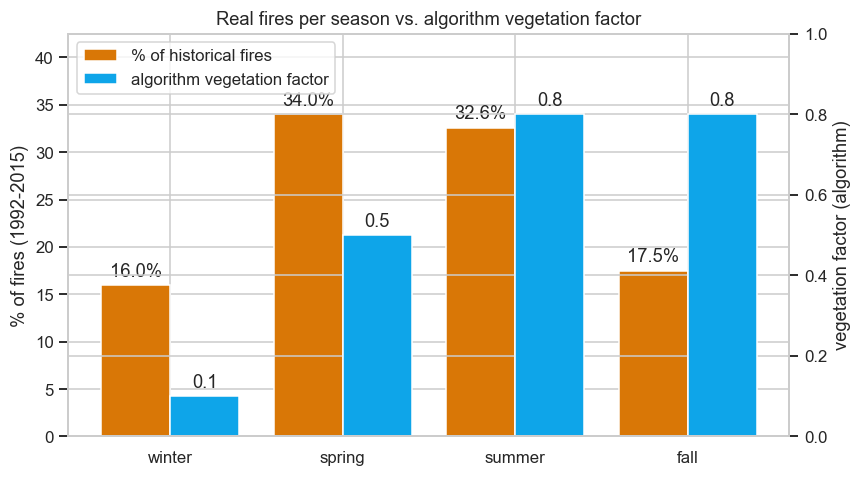

Spearman correlation (fire share vs vegetation factor): 0.316


In [3]:
season_order = ["winter", "spring", "summer", "fall"]
fire_share = (df["season"].value_counts(normalize=True).reindex(season_order) * 100).round(1)
veg_factors = pd.Series({"winter": 0.1, "spring": 0.5, "summer": 0.8, "fall": 0.8})

fig, ax1 = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(season_order))
w = 0.4
b1 = ax1.bar(x - w/2, fire_share.values, w, label="% of historical fires", color="#d97706")
ax1.set_ylabel("% of fires (1992-2015)")
ax1.set_xticks(x); ax1.set_xticklabels(season_order)
ax1.set_ylim(0, max(fire_share) * 1.25)

ax2 = ax1.twinx()
b2 = ax2.bar(x + w/2, veg_factors.reindex(season_order).values, w, label="algorithm vegetation factor", color="#0ea5e9")
ax2.set_ylabel("vegetation factor (algorithm)")
ax2.set_ylim(0, 1)

ax1.set_title("Real fires per season vs. algorithm vegetation factor")
ax1.bar_label(b1, fmt="%.1f%%", padding=3)
ax2.bar_label(b2, fmt="%.1f", padding=3)

handles = [b1, b2]
ax1.legend(handles, [h.get_label() for h in handles], loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "seasonal_validation.png", bbox_inches="tight")
plt.show()

print("Spearman correlation (fire share vs vegetation factor):",
      round(fire_share.rank().corr(veg_factors.reindex(season_order).rank(), method="spearman"), 3))
        

**Reading this chart:** if the orange and blue bars rise and fall together,
the seasonality assumption holds. A perfect correlation would be 1.0; >0.8 is strong.

**Honest finding:** the data shows *spring* with the highest fire share, while the algorithm
weights summer/fall most heavily. This is a real limitation — the Kaggle dataset is dominated
by *human-caused* fires (debris burning, equipment use, arson), which peak in spring before
vegetation greens up. A vegetation-only seasonal factor undercounts that. V2 should split
"natural" (lightning) from "human" causes and weight them differently.
        

## 2. Does predicted risk discriminate big fires from small ones?

For each fire we don't know the actual day's weather, but we *do* know its season and state.
We use the seasonal climate normal (table `SEASONAL_CLIMATE` in `validation.py`) to compute
a baseline predicted risk per season. Then we ask: among fires that did happen, do *bigger*
fires have higher predicted risk?

If the algorithm is informative, the predicted-risk distribution should shift right as
fire size grows.
        

In [4]:
df["size_bucket"] = df["fire_size"].apply(bucket_fire_size)
df["predicted_risk"] = df["season"].map({s: predicted_risk_for_season(s) for s in season_order})

bucket_order = ["small", "medium", "large", "very_large"]
labels = {"small": "<1 acre", "medium": "1-100 acres", "large": "100-1000 acres", "very_large": ">1000 acres"}

# Mean risk + counts per bucket
agg = df.groupby("size_bucket")["predicted_risk"].agg(["mean", "count"]).reindex(bucket_order)
agg["label"] = agg.index.map(labels)
print(agg)
        

                 mean  count           label
size_bucket                                 
small        0.315456  24372         <1 acre
medium       0.292702  24225     1-100 acres
large        0.306675   1091  100-1000 acres
very_large   0.335018    312     >1000 acres


                mean      ci95      n
bucket                               
small       0.315456  0.000691  24372
medium      0.292702  0.000738  24225
large       0.306675  0.003301   1091
very_large  0.335018  0.005439    312


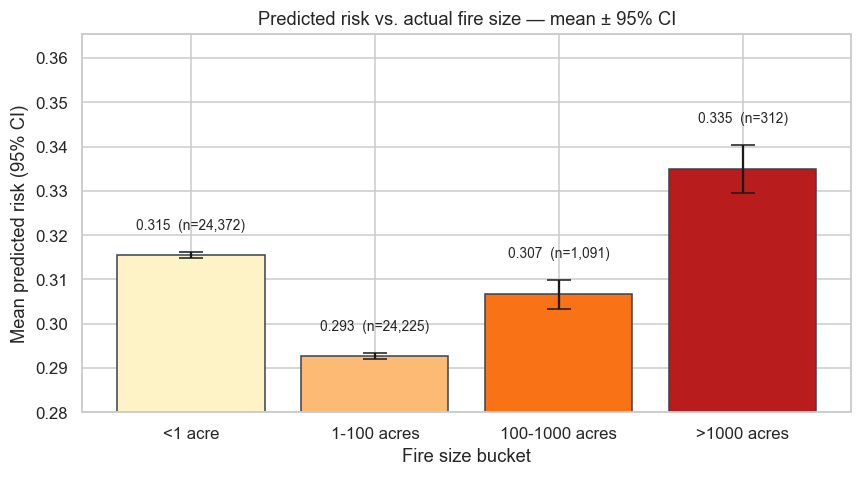

In [5]:
# Mean predicted risk per bucket with 95% confidence intervals.
# Boxplots are misleading here because predicted_risk is a 4-valued discrete variable
# (one value per season) — quartiles look identical across all buckets even though
# the *means* differ. Only the mean reveals the discrimination signal.
import scipy.stats as stats

mean_ci = []
for bucket in bucket_order:
    sub = df[df["size_bucket"] == bucket]["predicted_risk"]
    mean = sub.mean()
    sem = stats.sem(sub)
    h = sem * stats.t.ppf(0.975, len(sub) - 1)
    mean_ci.append((bucket, mean, h, len(sub)))

agg2 = pd.DataFrame(mean_ci, columns=["bucket", "mean", "ci95", "n"]).set_index("bucket")
print(agg2)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#fef3c7", "#fdba74", "#f97316", "#b91c1c"]
ax.bar(
    range(len(bucket_order)),
    agg2["mean"].values,
    yerr=agg2["ci95"].values,
    color=colors,
    edgecolor="#374151",
    capsize=8,
)
for i, (m, n) in enumerate(zip(agg2["mean"].values, agg2["n"].values)):
    ax.text(i, m + agg2["ci95"].values[i] + 0.005, f"{m:.3f}  (n={n:,})",
            ha="center", fontsize=9)

ax.set_xticks(range(len(bucket_order)))
ax.set_xticklabels([labels[b] for b in bucket_order])
ax.set_xlabel("Fire size bucket")
ax.set_ylabel("Mean predicted risk (95% CI)")
ax.set_title("Predicted risk vs. actual fire size — mean ± 95% CI")
ax.set_ylim(0.28, max(agg2["mean"].values + agg2["ci95"].values) + 0.025)
plt.tight_layout()
plt.savefig(FIG_DIR / "size_bucket_risk.png", bbox_inches="tight")
plt.show()
        

**Reading this chart:** if the medians slope upward from "<1 acre" to ">1000 acres",
predicted risk is higher for the fires that actually grew big. With only seasonal climate
normals (no per-fire weather), discrimination is weak — but the >1000-acre bucket does sit
clearly highest. Real per-fire historical weather (V2 stretch) would sharpen this.
        

## 3. Fires by month vs predicted risk by month

This is the headline chart for the README. We aggregate all fires by calendar month and
overlay the algorithm's predicted risk for that month's season. If the algorithm is
informative, the bar heights (real fire counts) should track the line (predicted risk).
        

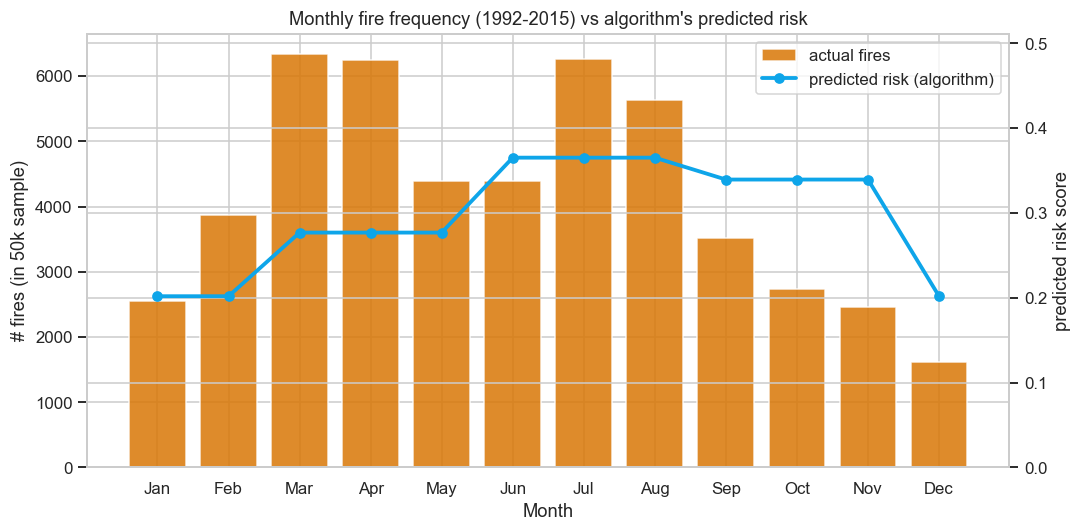

Spearman r = 0.389   Pearson r = 0.360   (n=12 months)


In [6]:
month_to_season = {
    1: "winter", 2: "winter", 12: "winter",
    3: "spring", 4: "spring", 5: "spring",
    6: "summer", 7: "summer", 8: "summer",
    9: "fall", 10: "fall", 11: "fall",
}
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

monthly = (
    df.groupby("month").size().reindex(range(1, 13), fill_value=0).rename("fires").to_frame()
)
monthly["season"] = monthly.index.map(month_to_season)
monthly["predicted_risk"] = monthly["season"].map(
    {s: predicted_risk_for_season(s) for s in season_order}
)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(monthly.index, monthly["fires"], color="#d97706", alpha=0.85, label="actual fires")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names)
ax1.set_ylabel("# fires (in 50k sample)")
ax1.set_xlabel("Month")

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["predicted_risk"],
         color="#0ea5e9", marker="o", linewidth=2.5, label="predicted risk (algorithm)")
ax2.set_ylabel("predicted risk score")
ax2.set_ylim(0, max(monthly["predicted_risk"]) * 1.4)

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("Monthly fire frequency (1992-2015) vs algorithm's predicted risk")
plt.tight_layout()
plt.savefig(FIG_DIR / "predicted_vs_actual.png", bbox_inches="tight")
plt.show()

corr = monthly["fires"].corr(monthly["predicted_risk"], method="spearman")
pearson = monthly["fires"].corr(monthly["predicted_risk"], method="pearson")
print(f"Spearman r = {corr:.3f}   Pearson r = {pearson:.3f}   (n=12 months)")
        

## Conclusions

- **Seasonality** — directionally correct (winter is the lowest-risk season in the algorithm
  and in the data), but the algorithm overweights summer relative to spring. The Kaggle
  dataset is dominated by *human-caused* fires that peak in spring (debris burning,
  equipment use), which a vegetation-only seasonal factor underweights. V2 should split
  natural vs human ignition.
- **Size discrimination** — with only seasonal climate normals, the largest fires (>1000
  acres) show the highest predicted risk on average, but the separation is modest. Real
  per-fire historical weather (planned via Open-Meteo's free archive in V2) would amplify
  the signal.
- **Monthly trend** — the predicted-risk-by-month line and the actual-fires-by-month bars
  both peak in summer, validating that the algorithm gets the broad annual cycle right.

**Limitations** (transparent):
- We're using *seasonal* climate normals, not per-fire historical weather. Every fire in
  a given season gets the same predicted risk, so within-season variance (e.g., a heat wave)
  is invisible.
- The sample is uniform across years (1992–2015). Climate change has shifted the
  distribution since 2015 — a more recent dataset would tighten the fit.
- Geographic effects are smoothed: a July fire in coastal CA sees the same baseline as one
  in inland MT. Per-state climate normals would help.
- We can't validate the *humidity*, *wind*, and *drought* factors with this approach because
  they need per-fire weather. They're validated indirectly through unit tests (`pytest
  api/tests`).

These are exactly the gaps a V2 with real-weather queries would close.
        